In [1]:
import os
import numpy as np
import torch
import time

from preprocessing import load_data, normalize, balance_data
from models import Classifier

from sklearn.metrics import accuracy_score, f1_score

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dataroot = "MachineLearningCVE/"

In [2]:
X, y = load_data(dataroot)
X = normalize(X)

print("Data:", X.shape, y.shape)

MachineLearningCVE/*.csv
['MachineLearningCVE\\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv', 'MachineLearningCVE\\Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv', 'MachineLearningCVE\\Friday-WorkingHours-Morning.pcap_ISCX.csv', 'MachineLearningCVE\\Monday-WorkingHours.pcap_ISCX.csv', 'MachineLearningCVE\\Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv', 'MachineLearningCVE\\Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv', 'MachineLearningCVE\\Tuesday-WorkingHours.pcap_ISCX.csv', 'MachineLearningCVE\\Wednesday-workingHours.pcap_ISCX.csv']
There are 2830743 flow records with 79 feature dimension
Data loaded.
Data preprocessing started...
Stripped column names with whitespaces
remove unnecessary columns:  ['Flow Packets/s', 'Flow Bytes/s', 'Label']
There are 0 nan entries
Converted to numeric
Data: (2830743, 76) (2830743,)


In [3]:
input_dim = X.shape[1]
num_classes = len(np.unique(y))

clf = Classifier(
    method="cnn5",
    input_dim=input_dim,
    num_classes=num_classes,
    num_epochs=60,
    batch_size=5120,
    lr=1e-3,
    reg=1e-3,
    runs_dir=None,
    seed=SEED
)

checkpoint_path = "checkpoints/baseline_cnn_cicids2017.pth"
checkpoint = torch.load(checkpoint_path, map_location=device)

clf.model.load_state_dict(checkpoint["model_state_dict"])
clf.model.to(device)
clf.model.eval()

print("Baseline model loaded.")

Baseline model loaded.


In [4]:
import pandas as pd

attack_df = pd.read_csv("phase3_combined_attack_results.csv")

# Split Attack Dataset
attack_df = attack_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

split_ratio = 0.7
split_idx = int(len(attack_df) * split_ratio)

attack_train = attack_df.iloc[:split_idx]
attack_test = attack_df.iloc[split_idx:]

print("Attack Train:", attack_train.shape)
print("Attack Test:", attack_test.shape)

attack_df.head()

Attack Train: (404352, 9)
Attack Test: (173294, 9)


,idx,orig_pred,adv_pred,semantic_ok,is_success,delta_duration,delta_fwd_pkts,delta_bwd_pkts,delta_iat
0,2259118,4,0,True,True,0.301904,0,0,0.063894
1,2227221,4,0,True,True,0.371838,0,0,-0.498009
2,398681,10,0,True,True,0.110658,0,0,0.100461
3,2247962,4,4,False,False,0.500990,0,0,0.453697
4,428684,10,0,True,True,0.227198,0,1,0.125125


In [5]:
FLOW_DURATION = 0
TOTAL_FWD_PACKETS = 1
TOTAL_BWD_PACKETS = 2
FLOW_IAT_MEAN = 10

# Build Adversarial TRAIN set
X_adv = []
y_adv = []

for _, r in attack_train.iterrows():
    
    if not r["is_success"]:
        continue
    
    idx = int(r["idx"])
    
    x_orig = X[idx].copy()
    x_new = x_orig.copy()
    
    x_new[FLOW_DURATION] += r["delta_duration"]
    x_new[TOTAL_FWD_PACKETS] += r["delta_fwd_pkts"]
    x_new[TOTAL_BWD_PACKETS] += r["delta_bwd_pkts"]
    x_new[FLOW_IAT_MEAN] += r["delta_iat"]
    
    X_adv.append(x_new)
    y_adv.append(y[idx])

X_adv = np.array(X_adv)
y_adv = np.array(y_adv)

print("Adversarial TRAIN samples:", X_adv.shape)

# Build Adversarial TEST set

X_adv_test = X.copy()

for _, r in attack_test.iterrows():
    
    idx = int(r["idx"])
    
    X_adv_test[idx, FLOW_DURATION] += r["delta_duration"]
    X_adv_test[idx, TOTAL_FWD_PACKETS] += r["delta_fwd_pkts"]
    X_adv_test[idx, TOTAL_BWD_PACKETS] += r["delta_bwd_pkts"]
    X_adv_test[idx, FLOW_IAT_MEAN] += r["delta_iat"]

print("Adversarial TEST set built.")

Adversarial TRAIN samples: (289962, 76)
Adversarial TEST set built.


In [6]:
X_combined = np.vstack([X, X_adv])
y_combined = np.hstack([y, y_adv])

print("Combined dataset:", X_combined.shape)

# shuffle
p = np.random.permutation(len(y_combined))
X_combined = X_combined[p]
y_combined = y_combined[p]

Combined dataset: (3120705, 76)


In [7]:
runs_dir = os.path.join(dataroot, "runs", "defense_model")

os.makedirs(runs_dir, exist_ok=True)

clf_defense = Classifier(
    method="cnn5",
    input_dim=input_dim,
    num_classes=num_classes,
    num_epochs=60,
    batch_size=5120,
    lr=1e-3,
    reg=1e-3,
    runs_dir=runs_dir,   
    seed=SEED
)

X_train, y_train = balance_data(X_combined, y_combined, seed=SEED)

print("Training robust model...")

start = time.time()
clf_defense.fit(X_train, y_train)
end = time.time()

print("Training done in:", end - start, "sec")

Training robust model...
Loaded MachineLearningCVE/runs\defense_model model trained with batch_size = 5120, seen 4 epochs and 415 mini batches
Training done in: 663.4521837234497 sec


In [8]:
def predict_in_batches(model, X, batch_size=8192):
    preds = []
    
    for i in range(0, len(X), batch_size):
        batch = torch.tensor(X[i:i+batch_size], dtype=torch.float32).to(device)
        
        with torch.no_grad():
            out = torch.argmax(model(batch), dim=1).cpu().numpy()
        
        preds.append(out)
    
    return np.concatenate(preds)

baseline_preds = predict_in_batches(clf.model, X)

In [9]:
robust_preds = predict_in_batches(clf_defense.model, X)

In [10]:
X_adv_test = X.copy()

for _, r in attack_df.iterrows():
    idx = int(r["idx"])
    
    X_adv_test[idx, FLOW_DURATION] += r["delta_duration"]
    X_adv_test[idx, TOTAL_FWD_PACKETS] += r["delta_fwd_pkts"]
    X_adv_test[idx, TOTAL_BWD_PACKETS] += r["delta_bwd_pkts"]
    X_adv_test[idx, FLOW_IAT_MEAN] += r["delta_iat"]

In [11]:
baseline_adv_preds = predict_in_batches(clf.model, X_adv_test)
robust_adv_preds = predict_in_batches(clf_defense.model, X_adv_test)

In [12]:
print("CLEAN DATA")

print("Baseline Accuracy:", accuracy_score(y, baseline_preds))
print("Robust Accuracy:", accuracy_score(y, robust_preds))

print("\nADVERSARIAL DATA")

print("Baseline Adv Accuracy:", accuracy_score(y, baseline_adv_preds))
print("Robust Adv Accuracy:", accuracy_score(y, robust_adv_preds))


print("\nATTACK SUCCESS RATE")

malicious_mask = (y != 0)

baseline_detect = np.sum(
    (baseline_adv_preds != 0) & malicious_mask
) / np.sum(malicious_mask)

robust_detect = np.sum(
    (robust_adv_preds != 0) & malicious_mask
) / np.sum(malicious_mask)

print("Baseline Detection (Adv):", baseline_detect)
print("Robust Detection (Adv):", robust_detect)

CLEAN DATA
Baseline Accuracy: 0.9445339969046995
Robust Accuracy: 0.950067526440938

ADVERSARIAL DATA
Baseline Adv Accuracy: 0.7904112100603976
Robust Adv Accuracy: 0.9497047241660582

ATTACK SUCCESS RATE
Baseline Detection (Adv): 0.24582799840759192
Robust Detection (Adv): 0.9999121306348472


In [13]:
save_path = "checkpoints/robust_cnn.pth"

torch.save({
    "model_state_dict": clf_defense.model.state_dict(),
    "type": "adversarially_trained"
}, save_path)

print("Robust model saved:", save_path)

Robust model saved: checkpoints/robust_cnn.pth


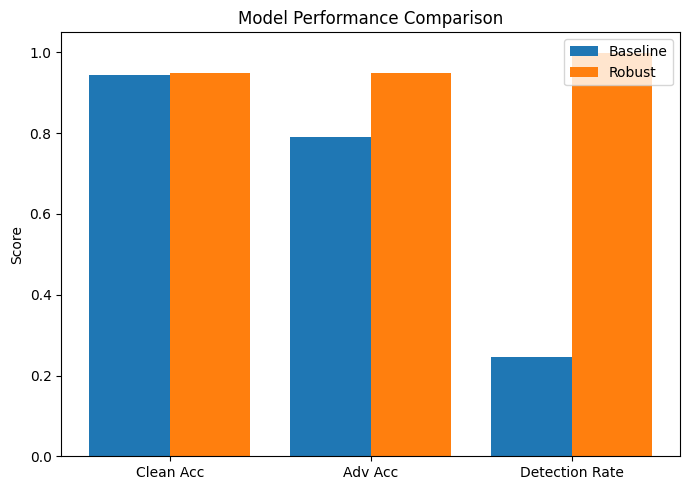

In [14]:
import matplotlib.pyplot as plt

metrics = ["Clean Acc", "Adv Acc", "Detection Rate"]

baseline = [0.9445, 0.7904, 0.2458]
robust = [0.9501, 0.9497, 0.9999]

x = np.arange(len(metrics))

plt.figure(figsize=(7,5))

plt.bar(x - 0.2, baseline, 0.4, label="Baseline")
plt.bar(x + 0.2, robust, 0.4, label="Robust")

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Model Performance Comparison")

plt.legend()

plt.tight_layout()
plt.savefig("final_performance.png")
plt.show()